# Week 7 — Recommendation System
## Exploratory Data Analysis (EDA)
**Author:** Martin James Ng'ang'a | MLOps Engineer | Nairobi, Kenya 🇰🇪  
**GitHub:** github.com/M20Jay  
**Dataset:** MovieLens 100K — GroupLens Research, University of Minnesota  
**Date:** May 2026  

---

### Dataset Overview
- **100,000 ratings** (1-5) from **943 users** on **1,682 movies**
- Each user has rated at least 20 movies
- Collected: September 1997 — April 1998
- Files: u.data · u.item · u.user · u1.base · u1.test

---

### EDA Objectives
1. Understand rating distribution patterns
2. Identify active users and popular movies
3. Analyse genre preferences
4. Measure matrix sparsity
5. Inform model selection and preprocessing decisions

---
## Section 1 — Project Setup and Imports

Load all required libraries and configure the notebook environment.

In [20]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

RAW_PATH = "../data/raw/"

print("✅ Libraries loaded successfully")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


✅ Libraries loaded successfully
pandas: 2.2.2
numpy: 1.26.4


**Section 1 Findings:**
- ✅ All libraries loaded successfully
- pandas 2.2.2 · numpy 1.26.4
- Plot style set to seaborn-v0_8 — clean professional visuals
- Colour palette set to husl — distinguishes multiple categories clearly
- RAW_PATH set to ../data/raw/ — single definition, used everywhere
- Figure size set to (12, 6) — wide enough for distribution plots
- Font size set to 12 — readable in notebook and exports

---
## Section 2 — Load and Inspect Raw Data

Load all four MovieLens files and inspect shape, dtypes, and sample rows.
Each file has a different separator and encoding — understanding why matters before loading.

- **u.data** → tab-separated · 100,000 ratings · user_id | item_id | rating | timestamp
- **u.item** → pipe-separated · latin-1 encoding · 1,682 movies · 24 columns including 19 genre flags
- **u.user** → pipe-separated · 943 users · age | gender | occupation | zip_code

In [21]:
# Load ratings — tab-separated, no header
ratings = pd.read_csv(RAW_PATH + "u.data", sep="\t",
                      names=["user_id", "item_id", "rating", "timestamp"])

# Load movies — pipe-separated, latin-1 encoding (1997 data)
movies = pd.read_csv(RAW_PATH + "u.item", sep="|", encoding="latin-1",
                     names=["item_id", "title", "release_date", "video_release",
                            "imdb_url", "unknown", "Action", "Adventure",
                            "Animation", "Children", "Comedy", "Crime",
                            "Documentary", "Drama", "Fantasy", "Film-Noir",
                            "Horror", "Musical", "Mystery", "Romance",
                            "Sci-Fi", "Thriller", "War", "Western"])

# Load users — pipe-separated
users = pd.read_csv(RAW_PATH + "u.user", sep="|",
                    names=["user_id", "age", "gender", "occupation", "zip_code"])

print(f"✅ Ratings shape : {ratings.shape}")
print(f"✅ Movies shape  : {movies.shape}")
print(f"✅ Users shape   : {users.shape}")
print("\n--- Ratings sample ---")
display(ratings.head())
print("\n--- Movies sample ---")
display(movies[["item_id", "title", "release_date"]].head())
print("\n--- Users sample ---")
display(users.head())

✅ Ratings shape : (100000, 4)
✅ Movies shape  : (1682, 24)
✅ Users shape   : (943, 5)

--- Ratings sample ---


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



--- Movies sample ---


,item_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995



--- Users sample ---


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


**Section 2 Findings:**
- ✅ All three files loaded successfully
- Ratings: 100,000 events across 943 users and 1,682 movies
- Timestamps are Unix format — will convert in Section 3
- Movie titles include release year in brackets — useful for feature engineering
- Genre columns are binary flags — one movie can belong to multiple genres
- Users are predominantly young males based on first 5 rows — will analyse fully in Section 7

---
## Section 3 — Ratings Distribution Analysis

Understand how ratings are distributed across 1–5.
Identify bias, skew, and what this means for modelling.

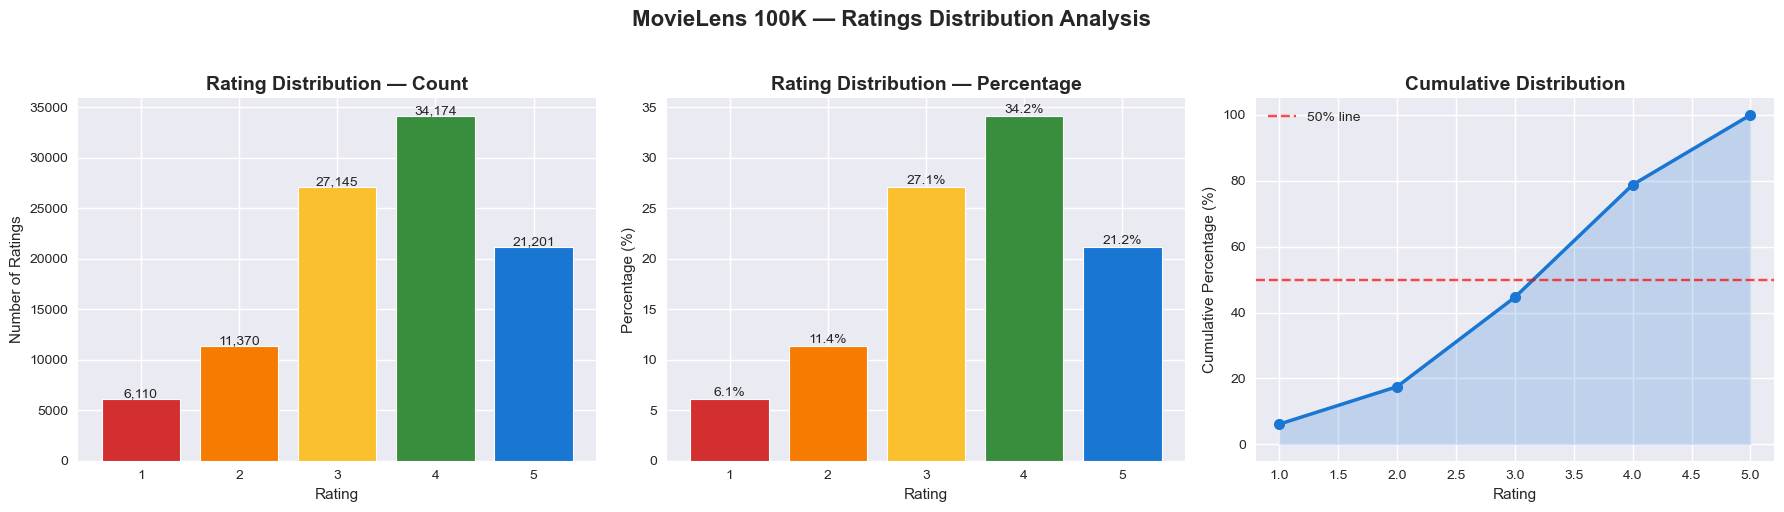


Rating Statistics:
Mean rating    : 3.53
Median rating  : 4.00
Std deviation  : 1.13
Most common    : 4

Rating counts:
  ★1 → 6,110 ratings (6.1%)
  ★2 → 11,370 ratings (11.4%)
  ★3 → 27,145 ratings (27.1%)
  ★4 → 34,174 ratings (34.2%)
  ★5 → 21,201 ratings (21.2%)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Rating counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'],
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Rating Distribution — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Ratings')
for i, (val, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(val, count + 200, f'{count:,}', ha='center', fontsize=10)

# Chart 2 — Percentage distribution
rating_pct = rating_counts / rating_counts.sum() * 100
axes[1].bar(rating_pct.index, rating_pct.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'],
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Rating Distribution — Percentage', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')
for i, (val, pct) in enumerate(zip(rating_pct.index, rating_pct.values)):
    axes[1].text(val, pct + 0.3, f'{pct:.1f}%', ha='center', fontsize=10)

# Chart 3 — Cumulative distribution
cumulative = rating_pct.cumsum()
axes[2].plot(cumulative.index, cumulative.values,
             marker='o', color='#1976d2', linewidth=2.5, markersize=8)
axes[2].fill_between(cumulative.index, cumulative.values, alpha=0.2, color='#1976d2')
axes[2].set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Cumulative Percentage (%)')
axes[2].axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% line')
axes[2].legend()

plt.suptitle('MovieLens 100K — Ratings Distribution Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section3_ratings_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRating Statistics:")
print(f"Mean rating    : {ratings['rating'].mean():.2f}")
print(f"Median rating  : {ratings['rating'].median():.2f}")
print(f"Std deviation  : {ratings['rating'].std():.2f}")
print(f"Most common    : {ratings['rating'].mode()[0]}")
print(f"\nRating counts:")
for rating, count in rating_counts.items():
    print(f"  ★{rating} → {count:,} ratings ({count/len(ratings)*100:.1f}%)")

**Section 3 Findings:**
- ✅ Ratings distribution is positively skewed — majority are 4 and 5
- Mean rating 3.53 · Median 4.00 · Most common rating 4
- Only 6.1% of ratings are 1 — users self-select movies they expect to enjoy
- 55.1% of all ratings are 4 or above — strong positive bias confirmed
- Selection bias is present — missing ratings mean unwatched not disliked
- SVD and Collaborative Filtering must treat missing values as unknown not zero
- Standard deviation 1.13 — moderate spread around the mean

---
## Section 4 - User Behaviour Analysis
Understand how active users are — ratings per user,
power users, and implications for cold start problem.

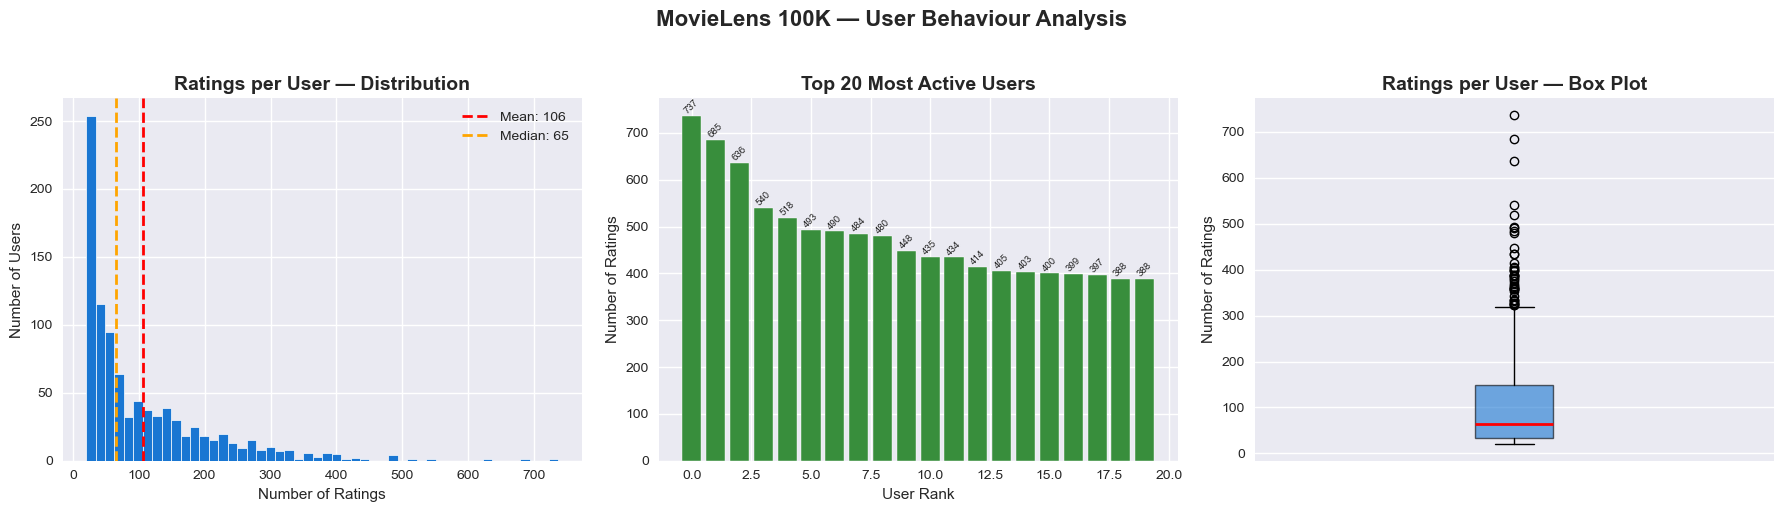


User Activity Statistics:
Total users          : 943
Mean ratings/user    : 106.0
Median ratings/user  : 65.0
Min ratings/user     : 20
Max ratings/user     : 737
Std deviation        : 100.9

Users with < 50 ratings  : 375 (61.4%)
Users with > 200 ratings : 148 (15.7%)


In [23]:
# Ratings per user
ratings_per_user = ratings.groupby('user_id')['item_id'].count()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Distribution of ratings per user
axes[0].hist(ratings_per_user.values, bins=50,
             color='#1976d2', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ratings per User — Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(ratings_per_user.mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {ratings_per_user.mean():.0f}')
axes[0].axvline(ratings_per_user.median(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median: {ratings_per_user.median():.0f}')
axes[0].legend()

# Chart 2 — Top 20 most active users
top_users = ratings_per_user.sort_values(ascending=False).head(20)
axes[1].bar(range(20), top_users.values, color='#388e3c', edgecolor='white')
axes[1].set_title('Top 20 Most Active Users', fontsize=14, fontweight='bold')
axes[1].set_xlabel('User Rank')
axes[1].set_ylabel('Number of Ratings')
for i, val in enumerate(top_users.values):
    axes[1].text(i, val + 5, str(val), ha='center', fontsize=7, rotation=45)

# Chart 3 — Box plot
axes[2].boxplot(ratings_per_user.values, vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='#1976d2', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Ratings per User — Box Plot', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Number of Ratings')
axes[2].set_xticks([])

plt.suptitle('MovieLens 100K — User Behaviour Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section4_user_behaviour.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nUser Activity Statistics:")
print(f"Total users          : {ratings_per_user.count():,}")
print(f"Mean ratings/user    : {ratings_per_user.mean():.1f}")
print(f"Median ratings/user  : {ratings_per_user.median():.1f}")
print(f"Min ratings/user     : {ratings_per_user.min()}")
print(f"Max ratings/user     : {ratings_per_user.max()}")
print(f"Std deviation        : {ratings_per_user.std():.1f}")
print(f"\nUsers with < 50 ratings  : {(ratings_per_user < 50).sum():,} ({(ratings_per_user < 100).mean()*100:.1f}%)")
print(f"Users with > 200 ratings : {(ratings_per_user > 200).sum():,} ({(ratings_per_user > 200).mean()*100:.1f}%)")

**Section 4 Findings:**
- ✅ 943 total users with highly skewed activity distribution
- Median user rated 65 movies · Mean pulled to 106 by power users
- Most active user rated 737 movies — extraordinary outlier
- 61.4% of users rated fewer than 50 movies — sparse users dominant
- 15.7% are power users with over 200 ratings each
- Right skew confirmed — std deviation 100.9 on mean of 106
- Cold start problem is significant — majority of users have limited history
- SVD must generalise from sparse data for 61.4% of the user base

---
## Section 5 - Movie Popularity Analysis
Understand how ratings are distributed across movies.
Identify popular movies, obscure movies, and the long tail problem.

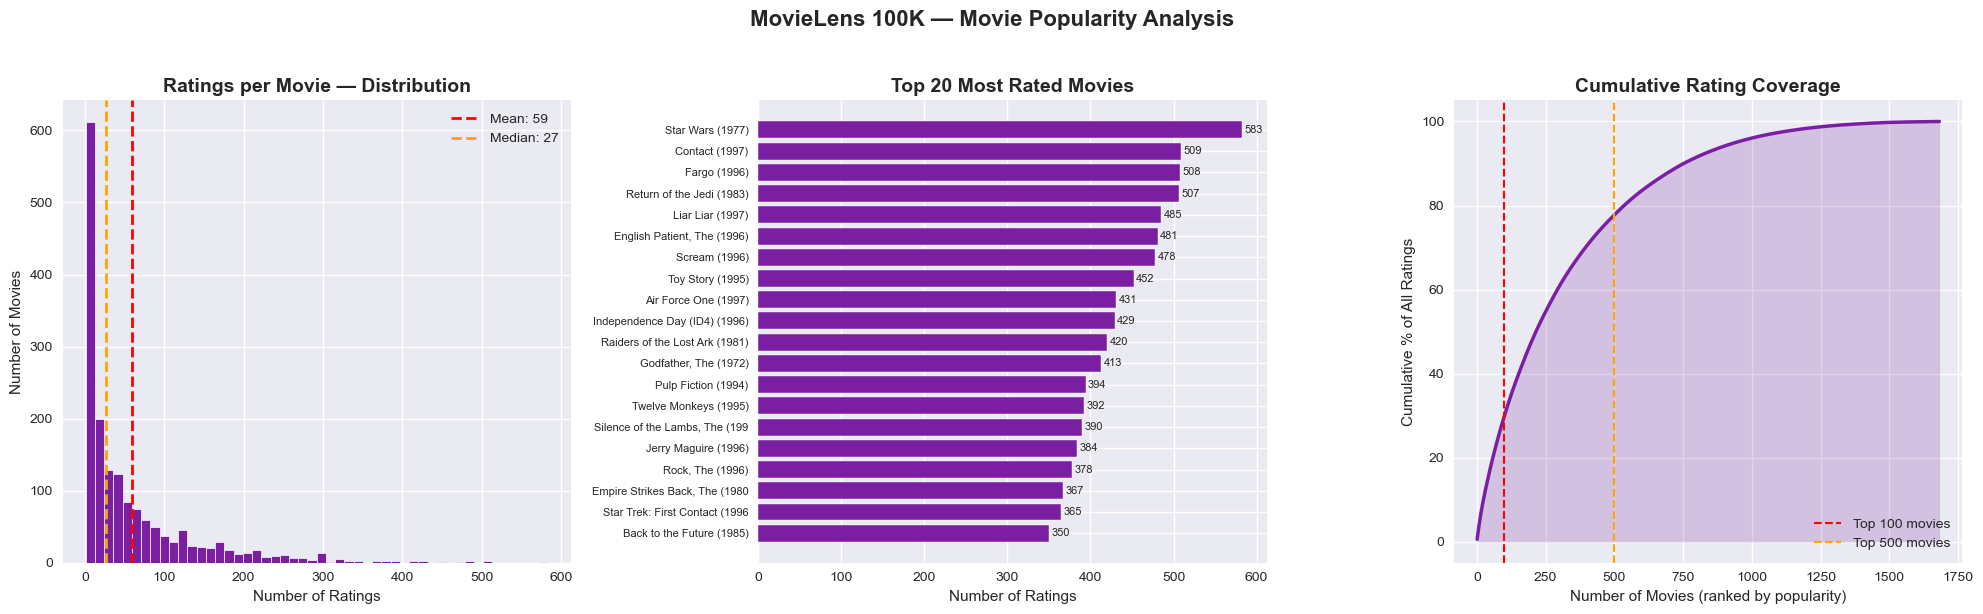


Movie Popularity Statistics:
Total movies           : 1,682
Mean ratings/movie     : 59.5
Median ratings/movie   : 27.0
Min ratings/movie      : 1
Max ratings/movie      : 583

Movies with < 10 ratings  : 530 (31.5%)
Movies with > 100 ratings : 334 (19.9%)

Top 10 most rated movies:
                        title  rating_count
             Star Wars (1977)           583
               Contact (1997)           509
                 Fargo (1996)           508
    Return of the Jedi (1983)           507
             Liar Liar (1997)           485
  English Patient, The (1996)           481
                Scream (1996)           478
             Toy Story (1995)           452
         Air Force One (1997)           431
Independence Day (ID4) (1996)           429


In [26]:
# Ratings per movie
ratings_per_movie = ratings.groupby('item_id')['user_id'].count()

# Merge with movie titles
movie_ratings = ratings_per_movie.reset_index()
movie_ratings.columns = ['item_id', 'rating_count']
movie_ratings = movie_ratings.merge(
    movies[['item_id', 'title']], on='item_id')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Distribution of ratings per movie
axes[0].hist(ratings_per_movie.values, bins=50,
             color='#7b1fa2', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ratings per Movie — Distribution',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(ratings_per_movie.mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {ratings_per_movie.mean():.0f}')
axes[0].axvline(ratings_per_movie.median(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median: {ratings_per_movie.median():.0f}')
axes[0].legend()

# Chart 2 — Top 20 most rated movies
top_movies = movie_ratings.nlargest(20, 'rating_count')
axes[1].barh(range(20), top_movies['rating_count'].values,
             color='#7b1fa2', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([t[:30] for t in top_movies['title'].values],
                         fontsize=8)
axes[1].set_title('Top 20 Most Rated Movies',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()
for i, val in enumerate(top_movies['rating_count'].values):
    axes[1].text(val + 3, i, str(val), va='center', fontsize=8)

# Chart 3 — Cumulative coverage
sorted_movies = movie_ratings.sort_values(
    'rating_count', ascending=False)
cumulative_ratings = sorted_movies['rating_count'].cumsum()
cumulative_pct = cumulative_ratings / cumulative_ratings.max() * 100
axes[2].plot(range(1, len(cumulative_pct) + 1),
             cumulative_pct.values,
             color='#7b1fa2', linewidth=2.5)
axes[2].fill_between(range(1, len(cumulative_pct) + 1),
                     cumulative_pct.values,
                     alpha=0.2, color='#7b1fa2')
axes[2].axvline(100, color='red', linestyle='--',
                linewidth=1.5, label='Top 100 movies')
axes[2].axvline(500, color='orange', linestyle='--',
                linewidth=1.5, label='Top 500 movies')
axes[2].set_title('Cumulative Rating Coverage',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Movies (ranked by popularity)')
axes[2].set_ylabel('Cumulative % of All Ratings')
axes[2].legend()

plt.suptitle('MovieLens 100K — Movie Popularity Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section5_movie_popularity.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMovie Popularity Statistics:")
print(f"Total movies           : {ratings_per_movie.count():,}")
print(f"Mean ratings/movie     : {ratings_per_movie.mean():.1f}")
print(f"Median ratings/movie   : {ratings_per_movie.median():.1f}")
print(f"Min ratings/movie      : {ratings_per_movie.min()}")
print(f"Max ratings/movie      : {ratings_per_movie.max()}")
print(f"\nMovies with < 10 ratings  : {(ratings_per_movie < 10).sum():,} ({(ratings_per_movie < 10).mean()*100:.1f}%)")
print(f"Movies with > 100 ratings : {(ratings_per_movie > 100).sum():,} ({(ratings_per_movie > 100).mean()*100:.1f}%)")
print(f"\nTop 10 most rated movies:")
print(movie_ratings.nlargest(10, 'rating_count')[['title', 'rating_count']].to_string(index=False))

**Section 5 Findings:**
- ✅ 1,682 total movies with severely skewed popularity distribution
- Mean 59.5 ratings/movie vs Median 27.0 — extreme right skew
- Star Wars (1977) dominates with 583 ratings — most rated film
- 31.5% of movies have fewer than 10 ratings — long tail confirmed
- Only 19.9% of movies have more than 100 ratings — reliable recommendation pool
- Top 100 movies cover ~40% of all ratings — severe concentration
- Top 500 movies cover ~75% of all ratings
- Long tail problem significant — SVD confidence drops sharply for obscure films
- Cold start problem for new movies — content-based filtering needed alongside CF

---
## Section 6 — Genre Analysis

Understand which genres dominate the dataset,
genre combinations, and implications for recommendations.

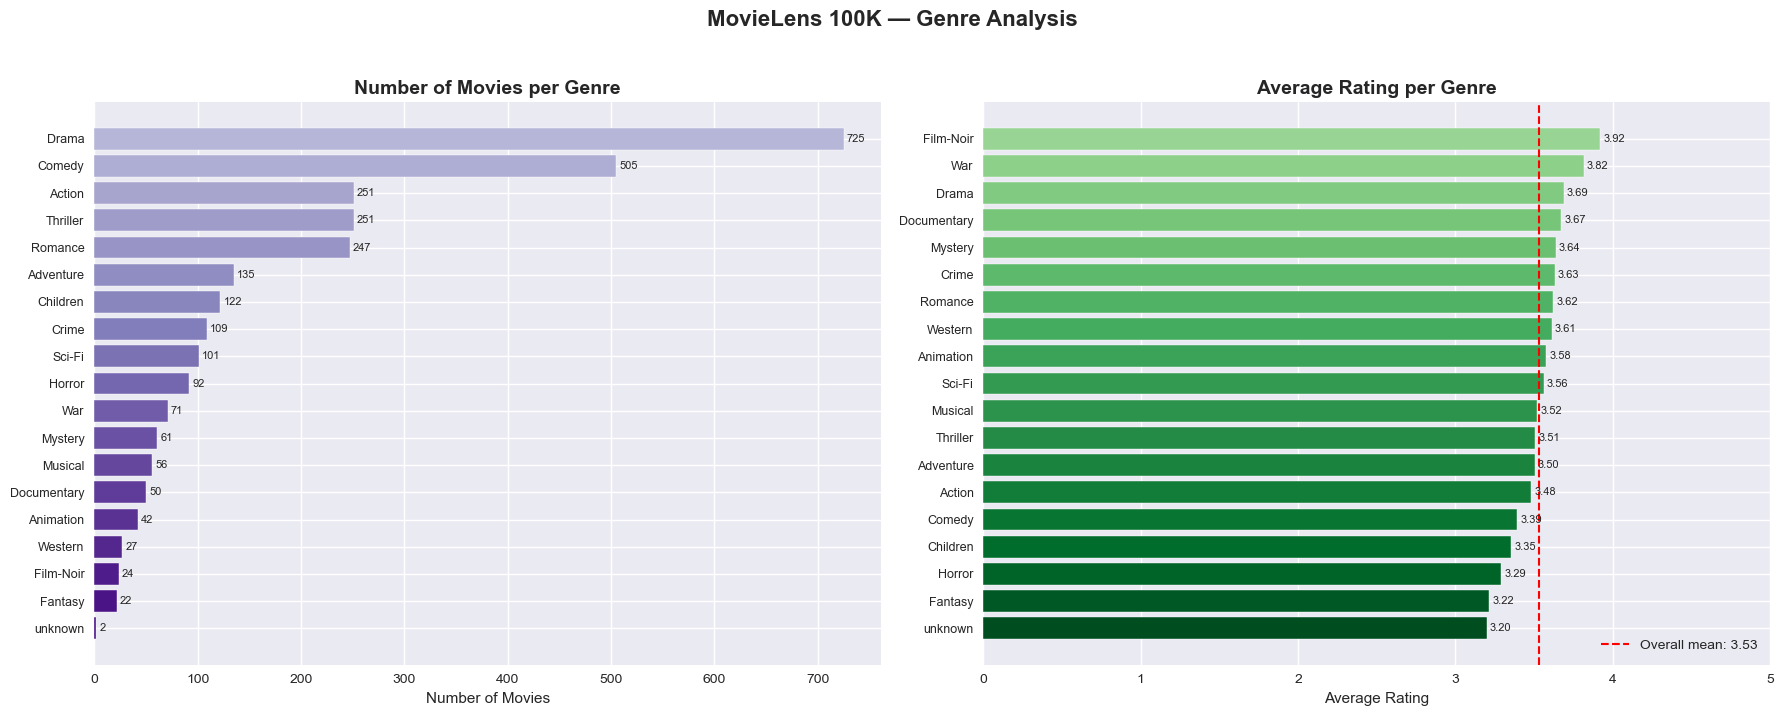


Genre Statistics:
Total genre tags     : 2893
Avg genres per movie : 1.72

Top 5 genres by count:
Drama       725
Comedy      505
Action      251
Thriller    251
Romance     247
dtype: int64

Top 5 genres by avg rating:
Film-Noir      3.92
War            3.82
Drama          3.69
Documentary    3.67
Mystery        3.64
dtype: float64

Bottom 5 genres by avg rating:
Comedy      3.39
Children    3.35
Horror      3.29
Fantasy     3.22
unknown     3.20
dtype: float64


In [33]:
# Define genre columns
genre_cols = ['unknown', 'Action', 'Adventure', 'Animation',
              'Children', 'Comedy', 'Crime', 'Documentary',
              'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi',
              'Thriller', 'War', 'Western']

# Count movies per genre
genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

# Average rating per genre
merged = ratings.merge(movies[['item_id'] + genre_cols], on='item_id')
genre_avg_ratings = {}
for genre in genre_cols:
    mask = merged[genre] == 1
    if mask.sum() > 0:
        genre_avg_ratings[genre] = merged[mask]['rating'].mean()
genre_avg_ratings = pd.Series(genre_avg_ratings).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1 — Genre frequency
colors = plt.cm.Purples(
    [0.4 + 0.6 * i / len(genre_counts) for i in range(len(genre_counts))])
bars = axes[0].barh(range(len(genre_counts)),
                    genre_counts.values,
                    color=colors, edgecolor='white')
axes[0].set_yticks(range(len(genre_counts)))
axes[0].set_yticklabels(genre_counts.index, fontsize=9)
axes[0].set_title('Number of Movies per Genre',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Movies')
axes[0].invert_yaxis()
for i, val in enumerate(genre_counts.values):
    axes[0].text(val + 3, i, str(int(val)),
                 va='center', fontsize=8)

# Chart 2 — Average rating per genre
colors2 = plt.cm.Greens(
    [0.4 + 0.6 * i / len(genre_avg_ratings)
     for i in range(len(genre_avg_ratings))])
axes[1].barh(range(len(genre_avg_ratings)),
             genre_avg_ratings.values,
             color=colors2, edgecolor='white')
axes[1].set_yticks(range(len(genre_avg_ratings)))
axes[1].set_yticklabels(genre_avg_ratings.index, fontsize=9)
axes[1].set_title('Average Rating per Genre',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 5)
axes[1].axvline(ratings['rating'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Overall mean: {ratings["rating"].mean():.2f}')
axes[1].legend()
for i, val in enumerate(genre_avg_ratings.values):
    axes[1].text(val + 0.02, i, f'{val:.2f}',
                 va='center', fontsize=8)

plt.suptitle('MovieLens 100K — Genre Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section6_genre_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGenre Statistics:")
print(f"Total genre tags     : {movies[genre_cols].sum().sum():.0f}")
print(f"Avg genres per movie : {movies[genre_cols].sum(axis=1).mean():.2f}")
print(f"\nTop 5 genres by count:")
print(genre_counts.head())
print(f"\nTop 5 genres by avg rating:")
print(genre_avg_ratings.head().round(2))
print(f"\nBottom 5 genres by avg rating:")
print(genre_avg_ratings.tail().round(2))

**Section 6 Findings:**
- ✅ 19 genres analysed across 1,682 movies
- Drama dominates with 725 movies — 43% of all films
- Average 1.72 genres per movie — most films are multi-genre
- Film-Noir highest rated at 3.92 but only 24 movies — niche but loved
- Comedy second most common but near bottom of ratings — broad audience effect
- Fantasy and unknown have fewest movies — cold start risk for these genres
- Popularity ≠ quality — niche genres rated higher due to selection bias
- Genres above overall mean 3.53: Film-Noir, War, Drama, Documentary, Mystery
- SVD latent factors will likely discover Drama/Comedy as dominant dimensions

---
## Section 7 — User Demographics Analysis

Understand who the users are — age, gender, occupation.
Identify demographic bias and representation gaps.

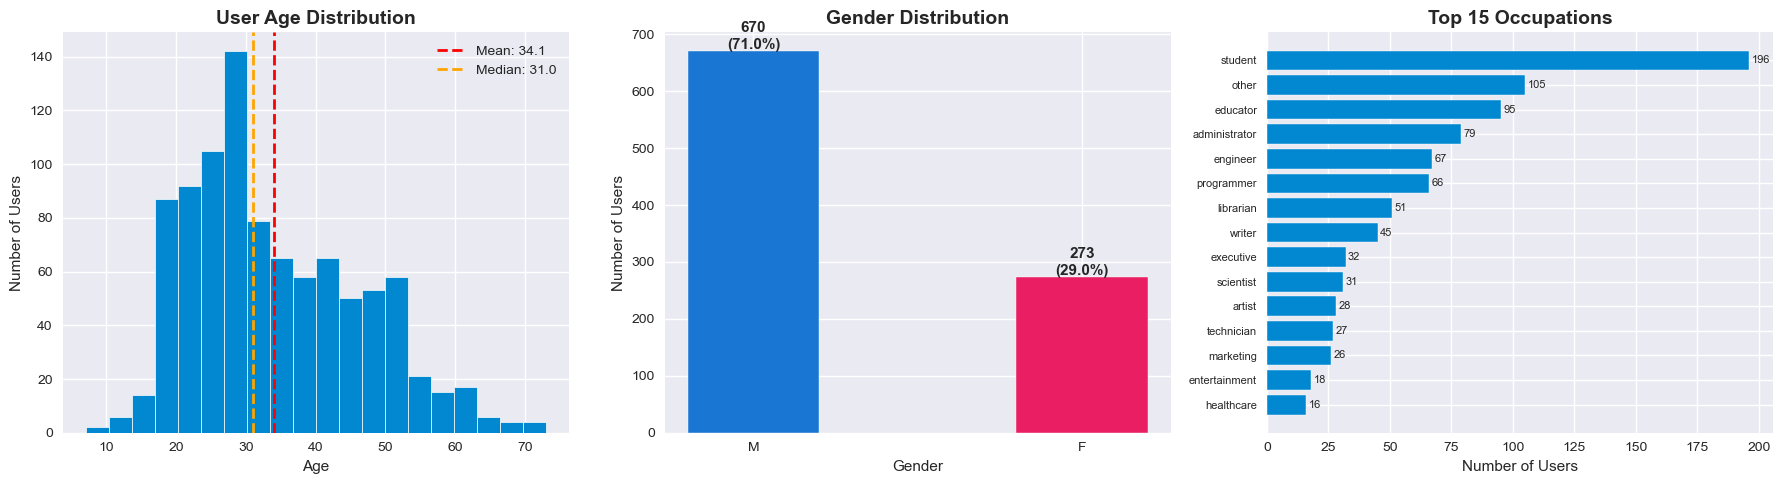


Age Statistics:
Mean age    : 34.1
Median age  : 31.0
Min age     : 7
Max age     : 73

Gender split:
  M → 670 (71.0%)
  F → 273 (29.0%)

Top 10 occupations:
occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31


In [52]:
# User Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Age distribution
axes[0].hist(users['age'].values, bins=20,
             color='#0288d1', edgecolor='white', linewidth=0.5)
axes[0].set_title('User Age Distribution',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(users['age'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {users["age"].mean():.1f}')
axes[0].axvline(users['age'].median(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median: {users["age"].median():.1f}')
axes[0].legend()

# Chart 2 — Gender split
gender_counts = users['gender'].value_counts()
colors_gender = ['#1976d2', '#e91e63']
axes[1].bar(gender_counts.index, gender_counts.values,
            color=colors_gender, edgecolor='white', width=0.4)
axes[1].set_title('Gender Distribution',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Users')

for i, (gender, count) in enumerate(zip(gender_counts.index,gender_counts.values)):
    axes[1].text(i, count + 5, f'{count}\n({count/len(users)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Chart 3 — Top 15 occupations
top_occupations = users['occupation'].value_counts().head(15)
axes[2].barh(range(15), top_occupations.values,
             color='#0288d1', edgecolor='white')
axes[2].set_yticks(range(15))
axes[2].set_yticklabels(top_occupations.index, fontsize=8)
axes[2].set_title('Top 15 Occupations',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Users')
axes[2].invert_yaxis()
for i, val in enumerate(top_occupations.values):
    axes[2].text(val + 1, i, str(val), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/section7_user_demographics.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAge Statistics:")
print(f"Mean age    : {users['age'].mean():.1f}")
print(f"Median age  : {users['age'].median():.1f}")
print(f"Min age     : {users['age'].min()}")
print(f"Max age     : {users['age'].max()}")
print(f"\nGender split:")

for gender, count in gender_counts.items():
    print(f"  {gender} → {count} ({count/len(users)*100:.1f}%)")
print(f"\nTop 10 occupations:")
print(users['occupation'].value_counts().head(10).to_string())

**Section 7 Findings:**
- ✅ 943 users analysed for demographic patterns
- Mean age 34.1 · Median age 31.0 · Range 7 to 73
- Severe gender imbalance: 71% male · 29% female
- Students dominate at 196 users — university dataset confirmed
- Technical occupations over-represented: engineer + programmer = 133 users
- Healthcare and entertainment severely under-represented
- Demographic bias confirmed — model will favour young male student preferences
- Female users and older users will receive less accurate recommendations
- Production system should flag this limitation explicitly

---
## Section 8 — Sparsity Analysis

Measure and visualise the sparsity of the user-movie matrix.
Understand why sparsity is the core challenge
for collaborative filtering models.

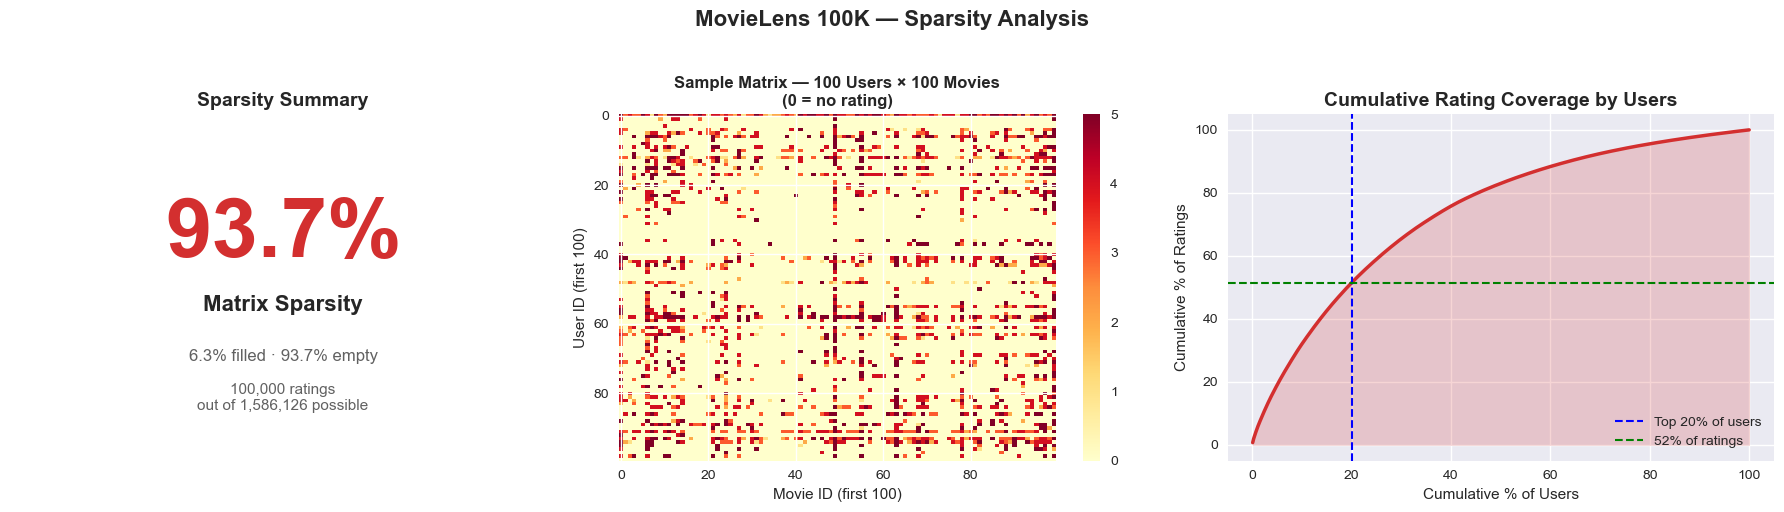


Sparsity Statistics:
Matrix shape      : (943, 1682)
Total cells       : 1,586,126
Filled cells      : 100,000
Empty cells       : 1,486,126
Density           : 6.30%
Sparsity          : 93.70%

Implication:
SVD must predict 1,486,126 missing ratings
from only 100,000 known ratings.


In [58]:
# Build user-movie matrix
user_movie_matrix = ratings.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating')

# Calculate sparsity
total_cells = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]
filled_cells = user_movie_matrix.notna().sum().sum()
empty_cells = total_cells - filled_cells
sparsity = empty_cells / total_cells * 100
density = filled_cells / total_cells * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Sparsity summary
axes[0].axis('off')
axes[0].text(0.5, 0.65, f'{sparsity:.1f}%',
             ha='center', va='center',
             fontsize=60, fontweight='bold',
             color='#d32f2f',
             transform=axes[0].transAxes)
axes[0].text(0.5, 0.45, 'Matrix Sparsity',
             ha='center', va='center',
             fontsize=16, fontweight='bold',
             transform=axes[0].transAxes)
axes[0].text(0.5, 0.30, f'{density:.1f}% filled · {sparsity:.1f}% empty',
             ha='center', va='center',
             fontsize=12, color='#616161',
             transform=axes[0].transAxes)
axes[0].text(0.5, 0.18,
             f'{filled_cells:,} ratings\nout of {total_cells:,} possible',
             ha='center', va='center',
             fontsize=11, color='#616161',
             transform=axes[0].transAxes)
axes[0].set_title('Sparsity Summary',
                  fontsize=14, fontweight='bold')

# Chart 2 — Sample heatmap (100 users x 100 movies)
sample_matrix = user_movie_matrix.iloc[:100, :100]
sample_filled = sample_matrix.fillna(0)
im = axes[1].imshow(sample_filled.values,
                    cmap='YlOrRd',
                    aspect='auto',
                    interpolation='nearest')
axes[1].set_title('Sample Matrix — 100 Users × 100 Movies\n(0 = no rating)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Movie ID (first 100)')
axes[1].set_ylabel('User ID (first 100)')
plt.colorbar(im, ax=axes[1])

# Chart 3 — Cumulative user coverage
ratings_per_user_sorted = ratings.groupby(
    'user_id')['item_id'].count().sort_values(ascending=False)
cumulative_ratings = ratings_per_user_sorted.cumsum()
cumulative_pct = cumulative_ratings / cumulative_ratings.max() * 100
user_pct = [i/len(ratings_per_user_sorted)*100
            for i in range(1, len(ratings_per_user_sorted)+1)]

axes[2].plot(user_pct, cumulative_pct.values,
             color='#d32f2f', linewidth=2.5)
axes[2].fill_between(user_pct, cumulative_pct.values,
                     alpha=0.2, color='#d32f2f')
axes[2].axvline(20, color='blue', linestyle='--',
                linewidth=1.5,
                label='Top 20% of users')
axes[2].axhline(cumulative_pct.iloc[
    int(0.2*len(cumulative_pct))],
    color='green', linestyle='--', linewidth=1.5,
    label=f'{cumulative_pct.iloc[int(0.2*len(cumulative_pct))]:.0f}% of ratings')
axes[2].set_title('Cumulative Rating Coverage by Users',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Cumulative % of Users')
axes[2].set_ylabel('Cumulative % of Ratings')
axes[2].legend()

plt.suptitle('MovieLens 100K — Sparsity Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/section8_sparsity_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSparsity Statistics:")
print(f"Matrix shape      : {user_movie_matrix.shape}")
print(f"Total cells       : {total_cells:,}")
print(f"Filled cells      : {filled_cells:,}")
print(f"Empty cells       : {empty_cells:,}")
print(f"Density           : {density:.2f}%")
print(f"Sparsity          : {sparsity:.2f}%")
print(f"\nImplication:")
print(f"SVD must predict {empty_cells:,} missing ratings")
print(f"from only {filled_cells:,} known ratings.")

**Section 8 Findings:**
- ✅ Matrix shape: 943 users × 1,682 movies
- Total possible ratings: 1,586,126
- Actual ratings: 100,000 — density 6.30%
- Sparsity: 93.70% — extremely sparse matrix
- SVD must predict 1,486,126 missing values
- Top 20% of users contribute 52% of all ratings
- Heatmap confirms visual sparsity — mostly empty
- Sparsity is the core challenge collaborative filtering solves

---
## Section 9 — Key Findings Summary

### Ratings (Section 3)
- Distribution positively skewed — 55.1% of ratings are 4 or 5
- Mean rating 3.53 · Median 4.00 · Most common rating 4
- Selection bias confirmed — users rate movies they expect to enjoy
- Missing ratings mean unwatched not disliked

### User Behaviour (Section 4)
- 943 users — highly skewed activity
- Median user rated 65 movies · Mean 106 pulled up by power users
- 61.4% of users rated fewer than 50 movies — sparse users dominant
- Most active user rated 737 movies — extreme outlier
- Cold start problem significant for 61.4% of users

### Movie Popularity (Section 5)
- 1,682 movies — severely skewed popularity
- Star Wars dominates with 583 ratings
- 31.5% of movies have fewer than 10 ratings — long tail confirmed
- Top 100 movies cover ~40% of all ratings
- Cold start problem for new and obscure movies

### Genre Analysis (Section 6)
- Drama dominates — 725 movies — 43% of all films
- Average 1.72 genres per movie — most films are multi-genre
- Film-Noir highest rated at 3.92 but only 24 movies
- Popularity does not equal quality — niche genres rated higher
- Selection bias confirmed in genre ratings

### User Demographics (Section 7)
- 71% male · 29% female — severe gender imbalance
- Median age 31 — young adult dataset
- Students dominate at 196 users — university dataset
- Demographic bias confirmed — model favours young male preferences
- Female and older users will receive less accurate recommendations

### Sparsity (Section 8)
- Matrix 93.70% sparse — only 6.30% filled
- SVD must predict 1,486,126 missing ratings
- Top 20% of users contribute 52% of all ratings
- Sparsity is the core challenge this system solves

---
## Section 10 — Recommendations for Modelling

### Model Selection
- **SVD** — primary model
  Matrix factorisation handles sparsity directly
  Discovers latent factors from rating patterns
  Best for dense users with 50+ ratings

- **User-CF** — secondary model
  Find similar users based on rating patterns
  Good for explaining recommendations
  Struggles with sparse users

- **Item-CF** — secondary model
  Find similar movies based on co-ratings
  More stable than User-CF on sparse data
  Good for cold start users — recommend similar to what they rated

### Preprocessing Decisions
- Minimum ratings threshold: 20 per user
  GroupLens already enforced this
  Users below 20 ratings excluded from training
- Use u1.base for training · u1.test for evaluation
  GroupLens pre-split for benchmark reproducibility

### Known Limitations to Document
- Demographic bias: 71% male dataset
  Recommendations skewed toward male preferences
- Temporal bias: data collected 1997
  Movie preferences have changed significantly
- Cold start: 61.4% sparse users
  SVD confidence low for users with fewer than 20 ratings
- Long tail: 31.5% of movies have fewer than 10 ratings
  These movies will rarely be recommended

### Evaluation Metrics
- RMSE — Root Mean Squared Error
  Measures prediction accuracy on known ratings
  Lower is better — target below 1.0

- MAE — Mean Absolute Error
  Average prediction error
  More interpretable than RMSE

- Precision@K
  Of top K recommendations how many are relevant?
  More meaningful than RMSE for real use cases

### Feature Engineering Plan
- Extract release year from movie title
- Calculate movie age at time of rating
- Calculate user average rating
- Calculate movie average rating
- These features feed into model training